<a href="https://colab.research.google.com/github/sakshimohite8/ML_Practicals_MCA/blob/main/02_Boston_Housing_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:

# 2_Modelling_Process_In_ML.ipynb

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns



In [3]:

data = pd.read_csv("/content/BostonHousing.csv")


In [4]:
data.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [6]:
data.shape

(506, 14)

In [7]:
data.isnull()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,False,False,False,False,False,False,False,False,False,False,False,False,False,False
502,False,False,False,False,False,False,False,False,False,False,False,False,False,False
503,False,False,False,False,False,False,False,False,False,False,False,False,False,False
504,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
data.isnull().sum()

,0
crim,0
zn,0
indus,0
chas,0
nox,0
rm,0
age,0
dis,0
rad,0
tax,0


In [10]:
data.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
501,False
502,False
503,False
504,False


In [11]:
data.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [12]:
data.empty

False

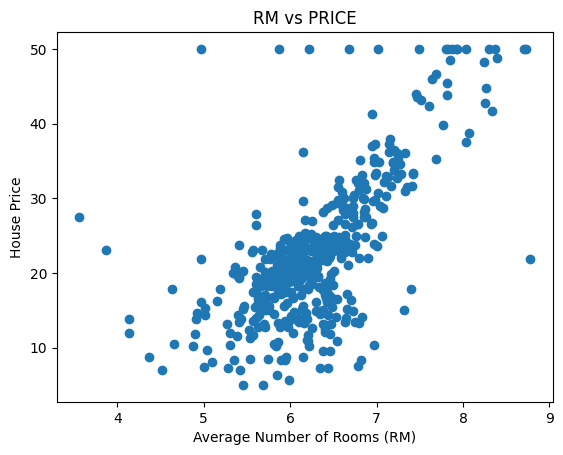

In [14]:
import matplotlib.pyplot as plt

plt.scatter(data["rm"], data["medv"])
plt.xlabel("Average Number of Rooms (RM)")
plt.ylabel("House Price")
plt.title("RM vs PRICE")
plt.show()

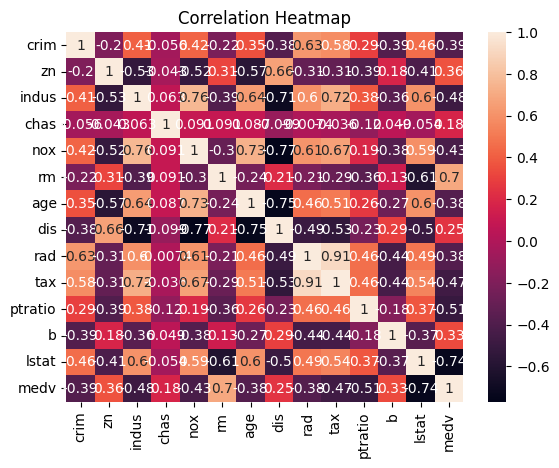

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=True)
plt.title("Correlation Heatmap")
plt.show()

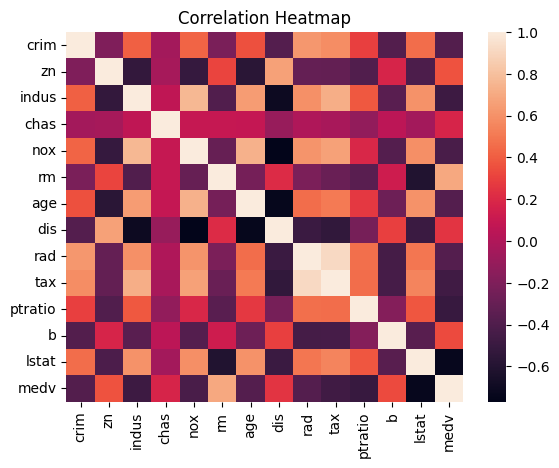

In [16]:
correlation = data.corr(numeric_only=True)
sns.heatmap(correlation, annot=False)
plt.title("Correlation Heatmap")
plt.show()

In [17]:
from sklearn.model_selection import train_test_split

# Import Features
X = data.drop('medv', axis=1)

# Target Variable
Y = data['medv']

# Split dataset into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (404, 13)
Testing data: (102, 13)


In [18]:
print("Training Data:")
print(X_train.head())

Training Data:
         crim    zn  indus  chas     nox     rm   age     dis  rad  tax  \
477  15.02340   0.0  18.10     0  0.6140  5.304  97.3  2.1007   24  666   
15    0.62739   0.0   8.14     0  0.5380  5.834  56.5  4.4986    4  307   
332   0.03466  35.0   6.06     0  0.4379  6.031  23.3  6.6407    1  304   
423   7.05042   0.0  18.10     0  0.6140  6.103  85.1  2.0218   24  666   
19    0.72580   0.0   8.14     0  0.5380  5.727  69.5  3.7965    4  307   

     ptratio       b  lstat  
477     20.2  349.48  24.91  
15      21.0  395.62   8.47  
332     16.9  362.25   7.83  
423     20.2    2.52  23.29  
19      21.0  390.95  11.28  


In [19]:
print("Testing Data:")
print(X_test.head())

Testing Data:
        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
173  0.09178   0.0   4.05     0  0.510  6.416  84.1  2.6463    5  296   
274  0.05644  40.0   6.41     1  0.447  6.758  32.9  4.0776    4  254   
491  0.10574   0.0  27.74     0  0.609  5.983  98.8  1.8681    4  711   
72   0.09164   0.0  10.81     0  0.413  6.065   7.8  5.2873    4  305   
452  5.09017   0.0  18.10     0  0.713  6.297  91.8  2.3682   24  666   

     ptratio       b  lstat  
173     16.6  395.50   9.04  
274     17.6  396.90   3.53  
491     20.1  390.11  18.07  
72      19.2  390.91   5.52  
452     20.2  385.09  17.27  


In [20]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, Y_train)
print("Model Trained Successfully")

Model Trained Successfully


In [21]:
model.predict(X_test)

array([28.99672362, 36.02556534, 14.81694405, 25.03197915, 18.76987992,
       23.25442929, 17.66253818, 14.34119   , 23.01320703, 20.63245597,
       24.90850512, 18.63883645, -6.08842184, 21.75834668, 19.23922576,
       26.19319733, 20.64773313,  5.79472718, 40.50033966, 17.61289074,
       27.24909479, 30.06625441, 11.34179277, 24.16077616, 17.86058499,
       15.83609765, 22.78148106, 14.57704449, 22.43626052, 19.19631835,
       22.43383455, 25.21979081, 25.93909562, 17.70162434, 16.76911711,
       16.95125411, 31.23340153, 20.13246729, 23.76579011, 24.6322925 ,
       13.94204955, 32.25576301, 42.67251161, 17.32745046, 27.27618614,
       16.99310991, 14.07009109, 25.90341861, 20.29485982, 29.95339638,
       21.28860173, 34.34451856, 16.04739105, 26.22562412, 39.53939798,
       22.57950697, 18.84531367, 32.72531661, 25.0673037 , 12.88628956,
       22.68221908, 30.48287757, 31.52626806, 15.90148607, 20.22094826,
       16.71089812, 20.52384893, 25.96356264, 30.61607978, 11.59

In [22]:
Y_pred = model.predict(X_test)

In [23]:
print("Prediction Values:", Y_pred[0:3])

Prediction Values: [28.99672362 36.02556534 14.81694405]


In [24]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(Y_test, Y_pred)
r2 = r2_score(Y_test, Y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R2 Score: {r2}")

Mean Squared Error: 24.291119474973478
R2 Score: 0.6687594935356326
